### Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/processed/traffic_volume_cleaned.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
0,Not Holiday,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,7.071068e-01,-0.707107,-0.866025,0.5
1,Not Holiday,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,5.000000e-01,-0.866025,-0.866025,0.5
2,Not Holiday,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2.588190e-01,-0.965926,-0.866025,0.5
3,Not Holiday,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,1.224647e-16,-1.000000,-0.866025,0.5
4,Not Holiday,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,-2.588190e-01,-0.965926,-0.866025,0.5


### Convert date_time & Sort Chronologically

In [3]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

### Define Features (X) and Target (y)

In [6]:
X = df.drop(columns=["traffic_volume", "date_time", "hour", "month"])
y = df["traffic_volume"]

X.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'day_of_week',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos']

### Chronological Train/Test Split

In [7]:
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32451
Testing samples: 8113


### Preprocessing Pipeline (Scaling + OHE)

In [8]:
categorical_features = ["holiday", "weather_main", "day_of_week"]

numerical_features = [
    "temp", "rain_1h", "snow_1h", "clouds_all",
    "hour_sin", "hour_cos", "month_sin", "month_cos"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

### Define Models

In [9]:
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
    ])
}

### Train & Evaluate All Models

In [10]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

c:\Users\ALNOUR\anaconda3\envs\sic\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ALNOUR\anaconda3\envs\sic\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ALNOUR\anaconda3\envs\sic\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Model,MAE,RMSE,R2
0,XGBoost,234.068680,379.521512,0.962894
1,Random Forest,250.915203,411.267859,0.956427
2,Linear Regression,821.574272,1042.941622,0.719787


### Visualize Model Comparison

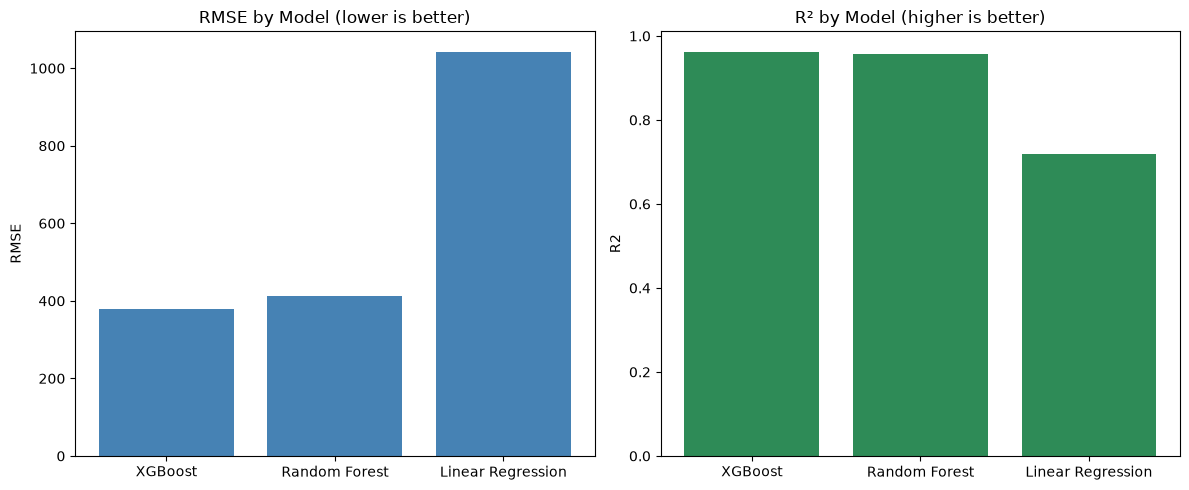

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")

axes[1].bar(results_df["Model"], results_df["R2"], color="seagreen")
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

### Select Best Model

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best performing model: {best_model_name}")
results_df

Best performing model: XGBoost


,Model,MAE,RMSE,R2
0,XGBoost,234.068680,379.521512,0.962894
1,Random Forest,250.915203,411.267859,0.956427
2,Linear Regression,821.574272,1042.941622,0.719787


### Train vs Test Performance (Overfitting Check)

In [13]:
best_pipeline = models[best_model_name]

y_train_pred = best_pipeline.predict(X_train)
y_test_pred = best_pipeline.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}   |   Test R²: {test_r2:.4f}")
print(f"Train MAE: {train_mae:.2f}   |   Test MAE: {test_mae:.2f}")

Train R²: 0.9689   |   Test R²: 0.9629
Train MAE: 219.55   |   Test MAE: 234.07


c:\Users\ALNOUR\anaconda3\envs\sic\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Why Encode `holiday` with Full Categories Instead of Binary?

Average traffic volume varies a lot between holiday types (e.g. Christmas Day ~1764 vs State Fair ~3837 — more than double). Some "holidays" like State Fair actually increase traffic instead of reducing it. Collapsing all holidays into a single binary flag would lose this distinction, so we keep the full categories and encode them with OHE.

In [15]:
df.groupby('holiday')['traffic_volume'].mean().sort_values()

holiday
Christmas Day                1764.283186
New Years Day                1794.526786
Thanksgiving Day             1995.990654
Memorial Day                 2095.649573
Independence Day             2155.175000
Labor Day                    2346.228814
Martin Luther King Jr Day    2732.362319
Washingtons Birthday         2830.547826
Veterans Day                 3301.759259
Not Holiday                  3313.464216
Columbus Day                 3393.533333
State Fair                   3837.100840
Name: traffic_volume, dtype: float64

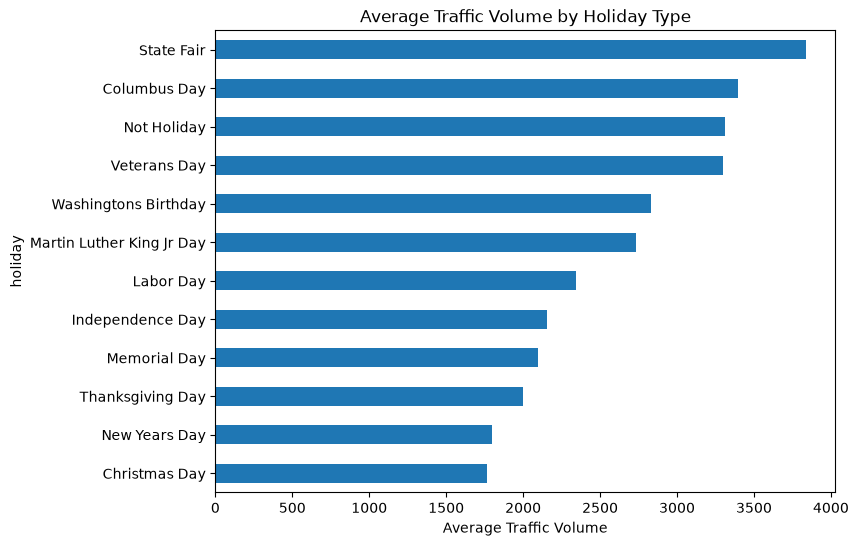

In [16]:
df.groupby('holiday')['traffic_volume'].mean().sort_values().plot(kind='barh', figsize=(8,6))
plt.xlabel('Average Traffic Volume')
plt.title('Average Traffic Volume by Holiday Type')
plt.show()